# 💳 Credit Card Fraud Detection
## Complete Data Preprocessing & Model Training Pipeline

End-to-end pipeline addressing extreme class imbalance (~0.39% fraud rate)  
using SMOTE, stratified cross-validation, class-weighted learning, and threshold optimisation.

**Dataset:** Simulated Credit Card Transaction Dataset (Kaggle — Sparkov)  
**Target:** `is_fraud` (0 = legitimate, 1 = fraud)

## 📦 Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import json, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost available ✓')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — skipping XGB comparison.')

RANDOM_STATE = 42
MODELS_DIR   = Path('../models')
BACKEND_ARTIFACTS_DIR = Path("../backend1/app/model_artifacts")
FIGURES_DIR  = Path('../figures')
DATA_DIR     = Path('../data')
MODELS_DIR.mkdir(exist_ok=True)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
BACKEND_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)    

print('All imports successful ✓')

XGBoost available ✓
All imports successful ✓


## Step 1: Load and Inspect Raw Data

Load the raw CSV and understand the dataset structure,
column types, missing values, and target class distribution.

In [ ]:
df_raw = pd.read_csv("../data/raw/fraudTest.csv")
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Shape: (555719, 23)
Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0


In [ ]:
print('=== Data Types ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print()
print('=== Target Distribution ===')
counts = df_raw['is_fraud'].value_counts()
print(counts)
print(f'\nFraud rate: {df_raw["is_fraud"].mean():.4%}')

=== Data Types ===
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

=== Missing Values ===
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                 

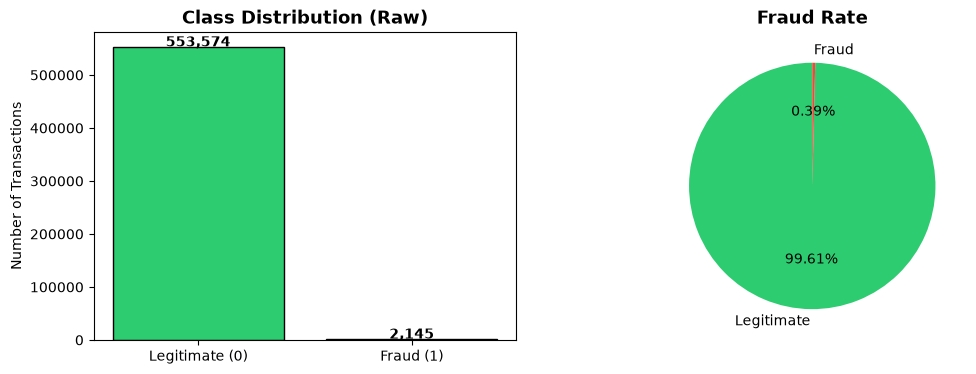

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    ['Legitimate (0)', 'Fraud (1)'],
    df_raw['is_fraud'].value_counts().values,
    color=['#2ecc71', '#e74c3c'], edgecolor='black'
)
axes[0].set_title('Class Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(df_raw['is_fraud'].value_counts().values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    df_raw['is_fraud'].value_counts().values,
    labels=['Legitimate', 'Fraud'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.2f%%', startangle=90
)
axes[1].set_title('Fraud Rate', fontsize=13, fontweight='bold')

plt.savefig('../figures/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
df_raw.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


## Step 2: Feature Engineering — Temporal Features

We engineer new features from the raw data **before** splitting.
These are purely row-wise transformations — no aggregation across rows — so no leakage.

| Feature | Source | Description |
|---|---|---|
| `trans_hour` | `trans_date_trans_time` | Hour of day (0-23). Fraud spikes at night |
| `trans_day` | `trans_date_trans_time` | Day of month (1-31) |
| `trans_weekday` | `trans_date_trans_time` | Day of week (0=Mon, 6=Sun) |
| `trans_month` | `trans_date_trans_time` | Month (1-12) |
| `age` | `dob` + `trans_date_trans_time` | Cardholder age at transaction time |


In [ ]:
def engineer_features(df):
    df = df.copy()
    dt  = pd.to_datetime(df['trans_date_trans_time'])
    dob = pd.to_datetime(df['dob'])

    df['trans_hour']    = dt.dt.hour
    df['trans_day']     = dt.dt.day
    df['trans_weekday'] = dt.dt.weekday
    df['trans_month']   = dt.dt.month
    df['age']           = (dt - dob).dt.days // 365
    return df

df = engineer_features(df_raw)
print('New features:', ['trans_hour','trans_day','trans_weekday','trans_month','age'])
df[['trans_hour','trans_day','trans_weekday','trans_month','age','is_fraud']].head()


New features: ['trans_hour', 'trans_day', 'trans_weekday', 'trans_month', 'age']


,trans_hour,trans_day,trans_weekday,trans_month,age,is_fraud
0,12,21,6,6,52,0
1,12,21,6,6,30,0
2,12,21,6,6,49,0
3,12,21,6,6,32,0
4,12,21,6,6,65,0


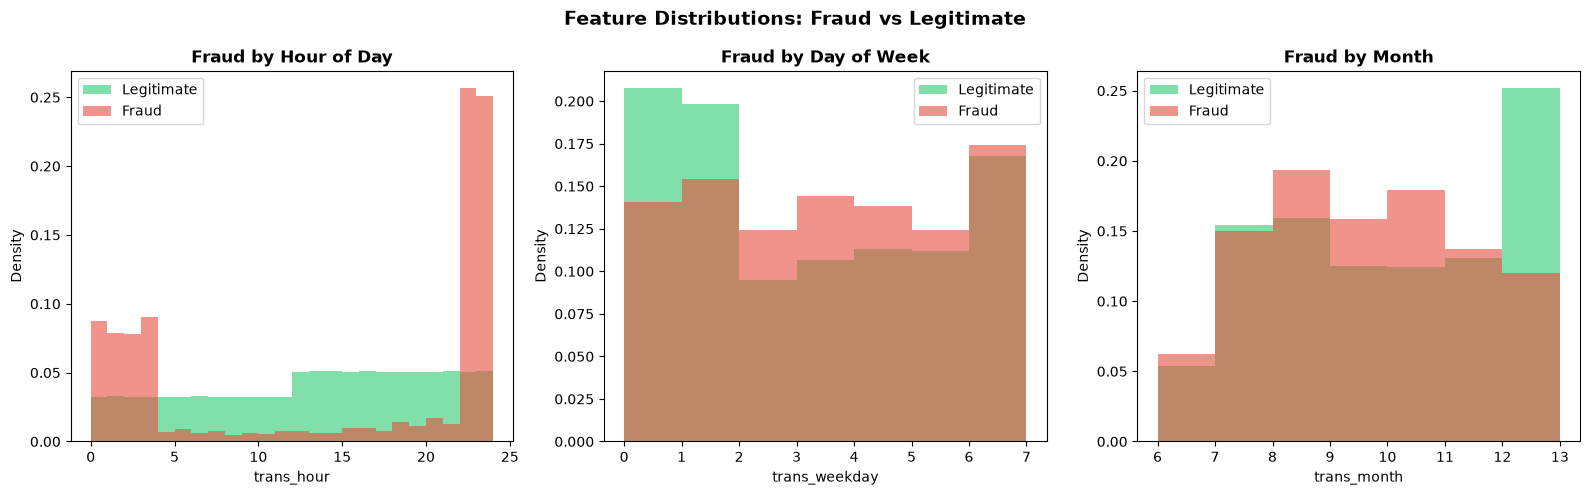

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_configs = [
    ('trans_hour',    'Fraud by Hour of Day'),
    ('trans_weekday', 'Fraud by Day of Week'),
    ('trans_month',   'Fraud by Month'),
]

for ax, (col, title) in zip(axes.flatten(), plot_configs):
    fraud_data = df.loc[df['is_fraud'] == 1, col]
    legit_data = df.loc[df['is_fraud'] == 0, col]
    bins = range(int(df[col].min()), int(df[col].max()) + 2)
    ax.hist(legit_data, bins=bins, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
    ax.hist(fraud_data, bins=bins, alpha=0.6, label='Fraud',      color='#e74c3c', density=True)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions: Fraud vs Legitimate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/temporal_patterns.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 3: Data Quality Checks

Verify the dataset before splitting:
- No remaining null values
- No duplicate rows
- Sensible value ranges for engineered features

In [ ]:
print('=== Null Values After Feature Engineering ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No null values ✓')

print(f'\n=== Duplicate Rows ===')
n_dup = df.duplicated().sum()
print(f'Duplicates found: {n_dup}')
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

print(f'\n=== Transaction Amount Stats ===')
print(df['amt'].describe())

print(f'\n=== Age Range ===')
print(f'Min: {df["age"].min()}, Max: {df["age"].max()}')


=== Null Values After Feature Engineering ===
No null values ✓

=== Duplicate Rows ===
Duplicates found: 0
Shape after removing duplicates: (555719, 28)

=== Transaction Amount Stats ===
count    555719.000000
mean         69.392810
std         156.745941
min           1.000000
25%           9.630000
50%          47.290000
75%          83.010000
max       22768.110000
Name: amt, dtype: float64

=== Age Range ===
Min: 15, Max: 96


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

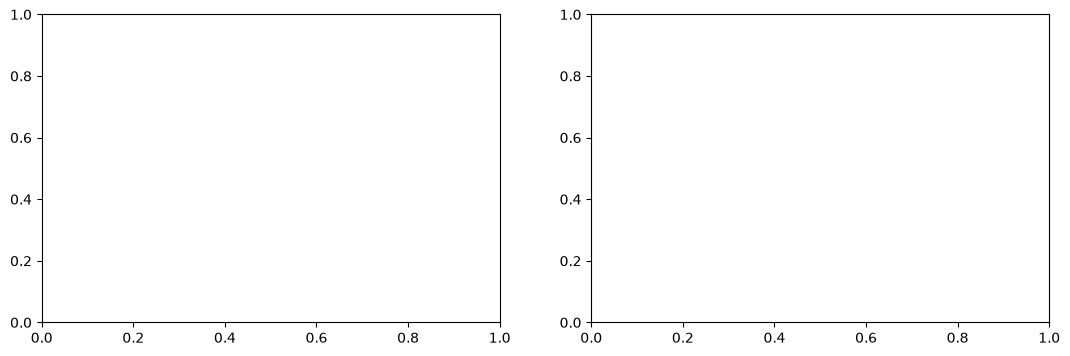

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot([
    df.loc[df['is_fraud'] == 0, 'amt'].clip(upper=500).values,
    df.loc[df['is_fraud'] == 1, 'amt'].clip(upper=500).values,
], labels=['Legitimate', 'Fraud'])
axes[0].set_title('Transaction Amount (capped $500)', fontweight='bold')
axes[0].set_ylabel('Amount ($)')

avg_amt = df.groupby(['category', 'is_fraud'])['amt'].mean().unstack()
avg_amt.columns = ['Legitimate', 'Fraud']
avg_amt.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Average Amount by Category', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/amount_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 4: Train-Test Split ⚠️ CRITICAL — Before Any Preprocessing

**Why split FIRST?**

| If we split AFTER preprocessing | If we split BEFORE (correct) |
|---|---|
| Scaler sees test data → leakage | Scaler only sees train data |
| Encoder uses test frequencies | Encoder uses only train frequencies |
| Performance estimate is optimistic | Performance estimate is realistic |

**Stratification** ensures both splits preserve the ~0.39% fraud rate.

In [ ]:
CATEGORY_VALUES = sorted(df['category'].unique().tolist())
print('Categories:', CATEGORY_VALUES)

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['is_fraud'], random_state=RANDOM_STATE
)

print(f'\nTrain size : {len(train_df):,}  ({len(train_df)/len(df):.0%})')
print(f'Test  size : {len(test_df):,}   ({len(test_df)/len(df):.0%})')
print(f'\nTrain fraud rate: {train_df["is_fraud"].mean():.4%}')
print(f'Test  fraud rate: {test_df["is_fraud"].mean():.4%}')
print('\nClass distribution preserved by stratification ✓')

Categories: ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel']

Train size : 444,575  (80%)
Test  size : 111,144   (20%)

Train fraud rate: 0.3860%
Test  fraud rate: 0.3860%

Class distribution preserved by stratification ✓


## Step 5: Feature Selection and Dropping

Remove columns that are:
- **Unique identifiers** — no predictive signal, cause overfitting (`cc_num`, `trans_num`)
- **PII** — first, last, street (privacy concern, not predictive)
- **Raw datetime** — already extracted into temporal features
- **Redundant location text** — zip, city (state is kept for frequency encoding)
- **Raw coordinates** — lat, long, merch_lat, merch_long (not used by any engineered feature; dropped directly)


In [ ]:
COLS_TO_DROP = [
    'Unnamed: 0',                              # CSV index artifact
    'cc_num', 'trans_num',                     # unique IDs — not predictive
    'first', 'last', 'street',                 # PII — irrelevant
    'dob',                                     # used to compute age
    'trans_date_trans_time',                   # used to compute temporal features
    'unix_time',                               # redundant with trans_date_trans_time
    'zip', 'city',                             # location text (state kept for freq-enc)
    'lat', 'long', 'merch_lat', 'merch_long',  # raw coordinates — not used by any feature
]

train_df = train_df.drop(columns=[c for c in COLS_TO_DROP if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in COLS_TO_DROP if c in test_df.columns])

print('Remaining columns:')
for c in train_df.columns:
    print(f'  {c}')
print(f'\nTrain shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')


Remaining columns:
  merchant
  category
  amt
  gender
  state
  city_pop
  job
  is_fraud
  trans_hour
  trans_day
  trans_weekday
  trans_month
  age

Train shape: (444575, 13)
Test  shape: (111144, 13)


## Step 6: Categorical Encoding — Fit on Train, Transform Both

| Feature | Method | Reason |
|---|---|---|
| `merchant`, `job`, `state` | Frequency Encoding | High-cardinality — replace with frequency in training data |
| `category` | One-Hot Encoding | Low-cardinality nominal feature |
| `gender` | Binary Encoding | F=0, M=1 |

**Critical:** All encoders fitted on **training data only**, then applied to test data.

In [ ]:
# ── Frequency Encoding ──────────────────────────────────────────────────────
def fit_frequency_map(df, col):
    return df[col].value_counts(normalize=True).to_dict()

def apply_frequency_map(df, col, freq_map, new_col):
    df = df.copy()
    df[new_col] = df[col].map(freq_map).fillna(0.0)
    return df

# Fit on train ONLY
freq_maps = {
    'merchant': fit_frequency_map(train_df, 'merchant'),
    'job':      fit_frequency_map(train_df, 'job'),
    'state':    fit_frequency_map(train_df, 'state'),
}
print(f'Frequency map sizes — merchant: {len(freq_maps["merchant"])}, '
      f'job: {len(freq_maps["job"])}, state: {len(freq_maps["state"])}')

# Apply to both splits
for col, new_col in [('merchant','merchant_enc'), ('job','job_enc'), ('state','state_enc')]:
    train_df = apply_frequency_map(train_df, col, freq_maps[col], new_col)
    test_df  = apply_frequency_map(test_df,  col, freq_maps[col], new_col)

# ── One-Hot Encoding (category) ─────────────────────────────────────────────
for cat in CATEGORY_VALUES:
    train_df[f'category_{cat}'] = (train_df['category'] == cat).astype(int)
    test_df[f'category_{cat}']  = (test_df['category']  == cat).astype(int)

# ── Binary Encoding (gender) ────────────────────────────────────────────────
train_df['gender'] = (train_df['gender'].str.upper() == 'M').astype(int)
test_df['gender']  = (test_df['gender'].str.upper()  == 'M').astype(int)

# Drop original categorical columns
RAW_CATS = ['merchant', 'job', 'state', 'category']
train_df = train_df.drop(columns=RAW_CATS)
test_df  = test_df.drop(columns=RAW_CATS)

print(f'Train shape after encoding: {train_df.shape}')
print(f'Test  shape after encoding: {test_df.shape}')

Frequency map sizes — merchant: 693, job: 478, state: 50
Train shape after encoding: (444575, 26)
Test  shape after encoding: (111144, 26)


## Step 7: Prepare Feature Matrices

In [ ]:
NUMERIC_FEATURES = [
    'amt', 'city_pop', 'age',
    'merchant_enc', 'job_enc',
    'trans_hour', 'trans_day', 'trans_weekday', 'trans_month',
]

TARGET       = 'is_fraud'
feature_cols = [c for c in train_df.columns if c != TARGET]
category_cols = [c for c in feature_cols if c.startswith('category_')]

print(f'Total features  : {len(feature_cols)}')
print(f'  Numeric       : {len(NUMERIC_FEATURES)}')
print(f'  Category OHE  : {len(category_cols)}')
print(f'  Passthrough   : {len(feature_cols) - len(NUMERIC_FEATURES) - len(category_cols)}')

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].values
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET].values

print(f'\nX_train: {X_train.shape}, fraud rate: {y_train.mean():.4%}')
print(f'X_test : {X_test.shape},  fraud rate: {y_test.mean():.4%}')


Total features  : 25
  Numeric       : 9
  Category OHE  : 14
  Passthrough   : 2

X_train: (444575, 25), fraud rate: 0.3860%
X_test : (111144, 25),  fraud rate: 0.3860%


## Step 8: Handle Class Imbalance with SMOTE (Training Data Only)

### What is SMOTE?
SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic fraud samples:
1. For each fraud sample, find its **k nearest neighbours** (k=5)
2. Draw a random neighbour
3. Create a new sample **along the line segment** between them

### Why SMOTE on training data ONLY?
- Test set must stay at original distribution (0.39% fraud) for realistic evaluation
- Applying SMOTE to test data makes recall look artificially high

### Target: 15% Fraud in Training Set
Going from 0.39% → 15% gives enough examples to learn patterns without overfitting.

Before SMOTE — fraud count: 1,716 (0.3860%)
After  SMOTE — fraud count: 78,151 (14.9999%)
Train grew from 444,575 → 521,010 rows


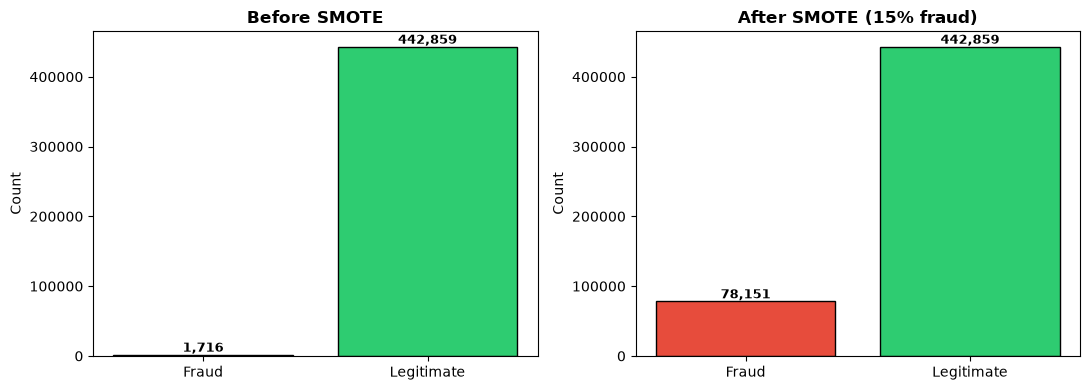

In [ ]:
print(f'Before SMOTE — fraud count: {y_train.sum():,} ({y_train.mean():.4%})')

# ratio = n_minority / n_majority to reach 15% fraud
SMOTE_RATIO = 0.15 / 0.85   # ≈ 0.176

smote = SMOTE(
    sampling_strategy=SMOTE_RATIO,
    random_state=RANDOM_STATE,
    k_neighbors=5,
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'After  SMOTE — fraud count: {y_train_res.sum():,} ({y_train_res.mean():.4%})')
print(f'Train grew from {len(X_train):,} → {len(X_train_res):,} rows')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(
    axes,
    [[y_train.sum(), (y_train==0).sum()], [y_train_res.sum(), (y_train_res==0).sum()]],
    ['Before SMOTE', 'After SMOTE (15% fraud)'],
):
    ax.bar(['Fraud', 'Legitimate'], counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.01, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/smote_effect.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 9: Feature Scaling — Fit on Resampled Train Only

**StandardScaler** normalises features to mean=0, std=1.

Only **numeric** features are scaled. One-hot and binary features are left as-is.

Scaler is fitted on **resampled training data only**, then applied to both sets.

In [ ]:
scaler = StandardScaler()

X_train_res_df = pd.DataFrame(X_train_res, columns=feature_cols)
X_train_df      = pd.DataFrame(X_train,     columns=feature_cols)   # NEW — unresampled
X_test_df      = pd.DataFrame(X_test,      columns=feature_cols)

# Fit on resampled train ONLY
X_train_res_df[NUMERIC_FEATURES] = scaler.fit_transform(X_train_res_df[NUMERIC_FEATURES])

# Transform test using train-fitted scaler (no leakage)
X_test_df[NUMERIC_FEATURES] = scaler.transform(X_test_df[NUMERIC_FEATURES])

print('Scaler fitted on resampled training data ✓')
print('Test data transformed (not fitted) ✓')
print(f'\nMeans after scaling (should be ≈ 0):')
print(X_train_res_df[NUMERIC_FEATURES].mean().round(4))

Scaler fitted on resampled training data ✓
Test data transformed (not fitted) ✓

Means after scaling (should be ≈ 0):
amt             -0.0
city_pop        -0.0
age             -0.0
merchant_enc     0.0
job_enc         -0.0
trans_hour      -0.0
trans_day       -0.0
trans_weekday    0.0
trans_month      0.0
dtype: float64


## Step 10: Convert Boolean Columns to Integer

In [ ]:
bool_cols = X_train_res_df.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    X_train_res_df[bool_cols] = X_train_res_df[bool_cols].astype(int)
    X_train_df[bool_cols]     = X_train_df[bool_cols].astype(int)   # NEW
    X_test_df[bool_cols]      = X_test_df[bool_cols].astype(int)
    print(f'Converted: {bool_cols}')
else:
    print('No boolean columns found ✓')

print(f'\nFinal X_train shape: {X_train_res_df.shape}')
print(f'Final X_test  shape: {X_test_df.shape}')
print(f'\nDtype counts:\n{X_train_res_df.dtypes.value_counts()}')

No boolean columns found ✓

Final X_train shape: (521010, 25)
Final X_test  shape: (111144, 25)

Dtype counts:
int64      15
float64    10
Name: count, dtype: int64


## Step 11: Save Preprocessed Data and Artifacts

In [ ]:
X_train_res_df['is_fraud'] = y_train_res
X_train_df['is_fraud']     = y_train        # NEW
X_test_df['is_fraud']      = y_test

X_train_res_df.to_csv(DATA_DIR / 'train_preprocessed.csv', index=False)
X_train_df.to_csv(DATA_DIR      / 'train_unresampled_preprocessed.csv', index=False)  # NEW
X_test_df.to_csv(DATA_DIR       / 'test_preprocessed.csv',  index=False)

joblib.dump(scaler,    MODELS_DIR / 'scaler.joblib')
joblib.dump(freq_maps, MODELS_DIR / 'freq_maps.joblib')

joblib.dump(scaler,    BACKEND_ARTIFACTS_DIR / 'scaler.joblib')
joblib.dump(freq_maps, BACKEND_ARTIFACTS_DIR / 'freq_maps.joblib')

with open(MODELS_DIR / 'feature_cols.json', 'w') as f:
    json.dump({
        'feature_cols':     feature_cols,
        'numeric_features': NUMERIC_FEATURES,
        'category_values':  CATEGORY_VALUES,
    }, f, indent=2)
with open(BACKEND_ARTIFACTS_DIR / 'feature_cols.json', 'w') as f:
    json.dump({
        'feature_cols':     feature_cols,
        'numeric_features': NUMERIC_FEATURES,
        'category_values':  CATEGORY_VALUES,
    }, f, indent=2)

print('Saved:')
print(f'  data/train_preprocessed.csv               ({len(X_train_res_df):,} rows, SMOTE-resampled — for final fit only)')
print(f'  data/train_unresampled_preprocessed.csv    ({len(X_train_df):,} rows — for CV/search)')
print(f'  data/test_preprocessed.csv                 ({len(X_test_df):,} rows)')
print(f'  models/scaler.joblib')
print(f'  models/freq_maps.joblib')
print(f'  models/feature_cols.json')

Saved:
  data/train_preprocessed.csv               (521,010 rows, SMOTE-resampled — for final fit only)
  data/train_unresampled_preprocessed.csv    (444,575 rows — for CV/search)
  data/test_preprocessed.csv                 (111,144 rows)
  models/scaler.joblib
  models/freq_maps.joblib
  models/feature_cols.json


---
# 🤖 Model Training and Evaluation Pipeline

## Step 12: Class Weight Configuration

Even after SMOTE, we use class weights as a secondary balancing mechanism.

| Strategy | Description | Best for |
|---|---|---|
| `balanced` | Weights ∝ 1/class_frequency | Most classifiers |
| `balanced_subsample` | Recomputes at each bootstrap | Random Forest |
| Manual `{0:1, 1:10}` | Full control | Fine-tuning cost ratios |

In [ ]:
train_pre      = pd.read_csv(DATA_DIR / 'train_preprocessed.csv')             # SMOTE-resampled — final fit only
train_unres    = pd.read_csv(DATA_DIR / 'train_unresampled_preprocessed.csv') # real distribution — CV/search
test_pre       = pd.read_csv(DATA_DIR / 'test_preprocessed.csv')

X_tr      = train_pre.drop(columns=['is_fraud'])      # resampled — used ONLY for the final single fit
y_tr      = train_pre['is_fraud'].values

X_tr_cv   = train_unres.drop(columns=['is_fraud'])    # real distribution — used for CV & search
y_tr_cv   = train_unres['is_fraud'].values

X_te      = test_pre.drop(columns=['is_fraud'])
y_te      = test_pre['is_fraud'].values

n_neg = (y_tr_cv == 0).sum() # type: ignore
n_pos = (y_tr_cv == 1).sum()
manual_weight = {0: 1, 1: int(n_neg / n_pos)}

print(f'Unresampled train — Legit: {n_neg:,}, Fraud: {n_pos:,} ({y_tr_cv.mean():.4%})')
print(f'Manual weight ratio: {{0: 1, 1: {manual_weight[1]}}}')
print(f'\nTest set (original distribution):')
print(f'  Legit: {(y_te==0).sum():,}, Fraud: {(y_te==1).sum():,} ({y_te.mean():.4%})')

Unresampled train — Legit: 442,859, Fraud: 1,716 (0.3860%)
Manual weight ratio: {0: 1, 1: 258}

Test set (original distribution):
  Legit: 110,715, Fraud: 429 (0.3860%)


## Step 13: Model Comparison — 5-Fold Stratified Cross-Validation

Comparing three models:
1. **Logistic Regression** — linear baseline
2. **Random Forest** — primary model
3. **XGBoost** — gradient boosting alternative

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['precision', 'recall', 'f1', 'average_precision']
SMOTE_RATIO = 0.15 / 0.85

def make_pipeline(clf):
    # SMOTE is refit on the TRAIN FOLD ONLY inside each CV split — no leakage
    return ImbPipeline([
        ('smote', SMOTE(sampling_strategy=float(SMOTE_RATIO), random_state=RANDOM_STATE, k_neighbors=5)),
        ('clf', clf),
    ])

models_to_compare = {
    'Logistic Regression': make_pipeline(LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
    'Random Forest': make_pipeline(RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
}
if XGBOOST_AVAILABLE:
    scale_pos = int(n_neg / n_pos)
    models_to_compare['XGBoost'] = make_pipeline(XGBClassifier(
         n_estimators=100,
        random_state=RANDOM_STATE, eval_metric='aucpr', verbosity=0
    ))

cv_results = {}
print('Running 5-fold cross-validation (SMOTE refit inside each fold)...')
for name, pipe in models_to_compare.items():
    t0     = time.time()
    scores = cross_validate(pipe, X_tr_cv, y_tr_cv, cv=cv, scoring=SCORING, n_jobs=-1)
    cv_results[name] = scores
    print(f'\n{name} ({time.time()-t0:.0f}s):')
    print(f'  Precision : {scores["test_precision"].mean():.3f} ± {scores["test_precision"].std():.3f}')
    print(f'  Recall    : {scores["test_recall"].mean():.3f} ± {scores["test_recall"].std():.3f}')
    print(f'  F1        : {scores["test_f1"].mean():.3f} ± {scores["test_f1"].std():.3f}')
    print(f'  PR-AUC    : {scores["test_average_precision"].mean():.3f} ± {scores["test_average_precision"].std():.3f}')

Running 5-fold cross-validation (SMOTE refit inside each fold)...

Logistic Regression (59s):
  Precision : 0.153 ± 0.008
  Recall    : 0.581 ± 0.029
  F1        : 0.242 ± 0.009
  PR-AUC    : 0.135 ± 0.008

Random Forest (85s):
  Precision : 0.864 ± 0.015
  Recall    : 0.752 ± 0.013
  F1        : 0.804 ± 0.013
  PR-AUC    : 0.855 ± 0.012

XGBoost (15s):
  Precision : 0.777 ± 0.009
  Recall    : 0.820 ± 0.008
  F1        : 0.798 ± 0.006
  PR-AUC    : 0.878 ± 0.007


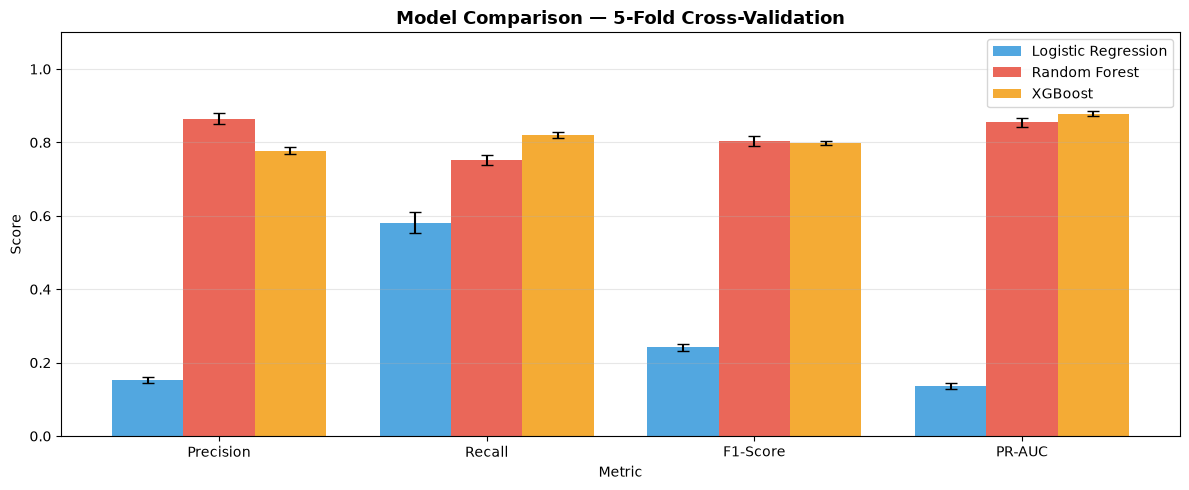

In [ ]:
metrics_display = ['test_precision', 'test_recall', 'test_f1', 'test_average_precision']
metric_labels   = ['Precision', 'Recall', 'F1-Score', 'PR-AUC']
colors = ['#3498db', '#e74c3c', '#f39c12']
x      = np.arange(len(metric_labels))
width  = 0.8 / len(cv_results)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, scores) in enumerate(cv_results.items()):
    means = [scores[m].mean() for m in metrics_display]
    stds  = [scores[m].std()  for m in metrics_display]
    ax.bar(x + i*width - width*(len(cv_results)-1)/2, means,
           width, label=name, color=colors[i], yerr=stds, capsize=4, alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — 5-Fold Cross-Validation', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/model_comparison_cv.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 14: Hyperparameter Tuning — RandomizedSearchCV

Search on an 80k-row stratified subsample for speed,
then **refit best params on the full training set**.

In [ ]:
param_dist = {
    'clf__n_estimators':      [100, 150, 200, 300],
    'clf__max_depth':         [10, 15, 20, 25, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4],
    'clf__max_features':      ['sqrt', 'log2'],
}

search_idx, _ = train_test_split(
    np.arange(len(X_tr_cv)), train_size=min(80_000, len(X_tr_cv)),
    stratify=y_tr_cv, random_state=RANDOM_STATE,
)
X_search = X_tr_cv.iloc[search_idx]
y_search = y_tr_cv[search_idx]

search_pipe = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=SMOTE_RATIO, random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE, n_jobs=-1
    )),
])

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    search_pipe, param_dist, n_iter=20, scoring='average_precision',
    cv=cv3, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_search, y_search)

# strip the 'clf__' prefix so params are ready to hand to a plain RandomForestClassifier
best_params = {k.replace('clf__', ''): v for k, v in search.best_params_.items()}
print(f'\nBest params: {best_params}')
print(f'Best CV PR-AUC: {search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV PR-AUC: 0.6290


In [ ]:
print('Refitting best params on FULL (SMOTE-resampled) training set...')
t0 = time.time()
best_rf = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_rf.fit(X_tr, y_tr)  # X_tr/y_tr = resampled full train set — single fit, no leakage here
print(f'Done in {time.time()-t0:.1f}s ✓')

Refitting best params on FULL (SMOTE-resampled) training set...
Done in 36.1s ✓


## Step 15: Threshold Optimisation

Default threshold of **0.5** is rarely optimal for imbalanced data.
We search 0.05→0.95 and pick the threshold maximising F1-score.

- Lower threshold → higher recall (catch more fraud) → more false alarms
- Higher threshold → higher precision (fewer false alarms) → miss more fraud

Optimal threshold : 0.49
  Precision       : 0.8409
  Recall          : 0.7762
  F1              : 0.8073


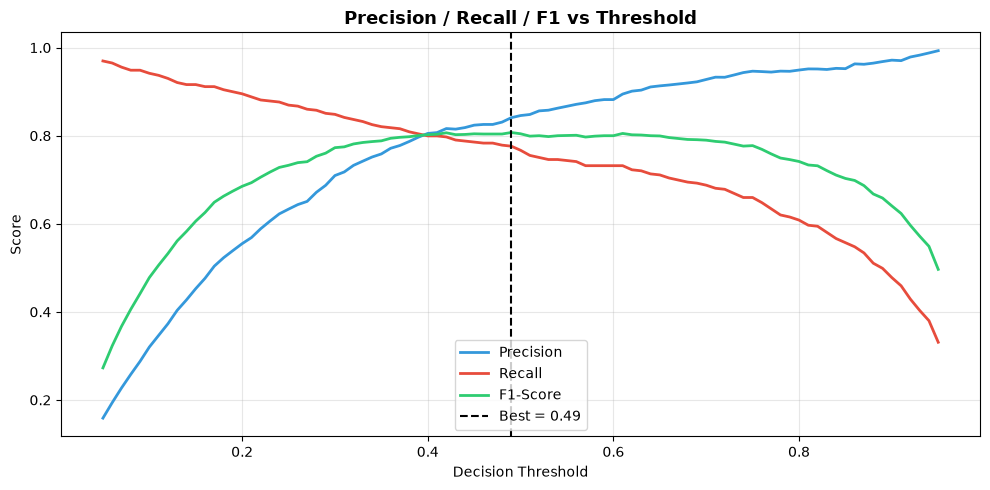

In [ ]:
y_proba_rf = best_rf.predict_proba(X_te)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
results = []
for t in thresholds:
    preds = (y_proba_rf >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_te, preds, zero_division=0),
        'recall':    recall_score(y_te, preds, zero_division=0),
        'f1':        f1_score(y_te, preds, zero_division=0),
    })

threshold_df   = pd.DataFrame(results)
best_row       = threshold_df.loc[threshold_df['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])

print(f'Optimal threshold : {BEST_THRESHOLD:.2f}')
print(f'  Precision       : {best_row["precision"]:.4f}')
print(f'  Recall          : {best_row["recall"]:.4f}')
print(f'  F1              : {best_row["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', color='#3498db', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['recall'],    label='Recall',    color='#e74c3c', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['f1'],        label='F1-Score',  color='#2ecc71', lw=2)
ax.axvline(BEST_THRESHOLD, color='black', linestyle='--', label=f'Best = {BEST_THRESHOLD:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/threshold_optimisation.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 16: Comprehensive Evaluation

In [ ]:
y_pred_rf = (y_proba_rf >= BEST_THRESHOLD).astype(int)

precision = precision_score(y_te, y_pred_rf, zero_division=0)
recall    = recall_score(y_te, y_pred_rf, zero_division=0)
f1        = f1_score(y_te, y_pred_rf, zero_division=0)
pr_auc    = average_precision_score(y_te, y_proba_rf)
roc_auc   = roc_auc_score(y_te, y_proba_rf)
cm        = confusion_matrix(y_te, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print('=' * 50)
print('  FINAL MODEL PERFORMANCE — TEST SET')
print('=' * 50)
print(f'  Threshold   : {BEST_THRESHOLD:.2f}')
print(f'  Precision   : {precision:.4f}  ({precision:.2%})')
print(f'  Recall      : {recall:.4f}  ({recall:.2%})')
print(f'  F1-Score    : {f1:.4f}  ({f1:.2%})')
print(f'  PR-AUC      : {pr_auc:.4f}  ({pr_auc:.2%})')
print(f'  ROC-AUC     : {roc_auc:.4f}  ({roc_auc:.2%})')
print(f'\n  Confusion Matrix:')
print(f'    True  Negatives (correct legit) : {tn:,}')
print(f'    False Positives (false alarms)  : {fp:,}  ({fp/(fp+tn):.2%} of legit)')
print(f'    False Negatives (missed frauds) : {fn:,}  ({fn/(fn+tp):.2%} of fraud)')
print(f'    True  Positives (caught fraud)  : {tp:,}  ({tp/(tp+fn):.2%} of fraud)')
print('=' * 50)
print(classification_report(y_te, y_pred_rf, target_names=['Legitimate', 'Fraud']))

  FINAL MODEL PERFORMANCE — TEST SET
  Threshold   : 0.49
  Precision   : 0.8409  (84.09%)
  Recall      : 0.7762  (77.62%)
  F1-Score    : 0.8073  (80.73%)
  PR-AUC      : 0.8671  (86.71%)
  ROC-AUC     : 0.9964  (99.64%)

  Confusion Matrix:
    True  Negatives (correct legit) : 110,652
    False Positives (false alarms)  : 63  (0.06% of legit)
    False Negatives (missed frauds) : 96  (22.38% of fraud)
    True  Positives (caught fraud)  : 333  (77.62% of fraud)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    110715
       Fraud       0.84      0.78      0.81       429

    accuracy                           1.00    111144
   macro avg       0.92      0.89      0.90    111144
weighted avg       1.00      1.00      1.00    111144



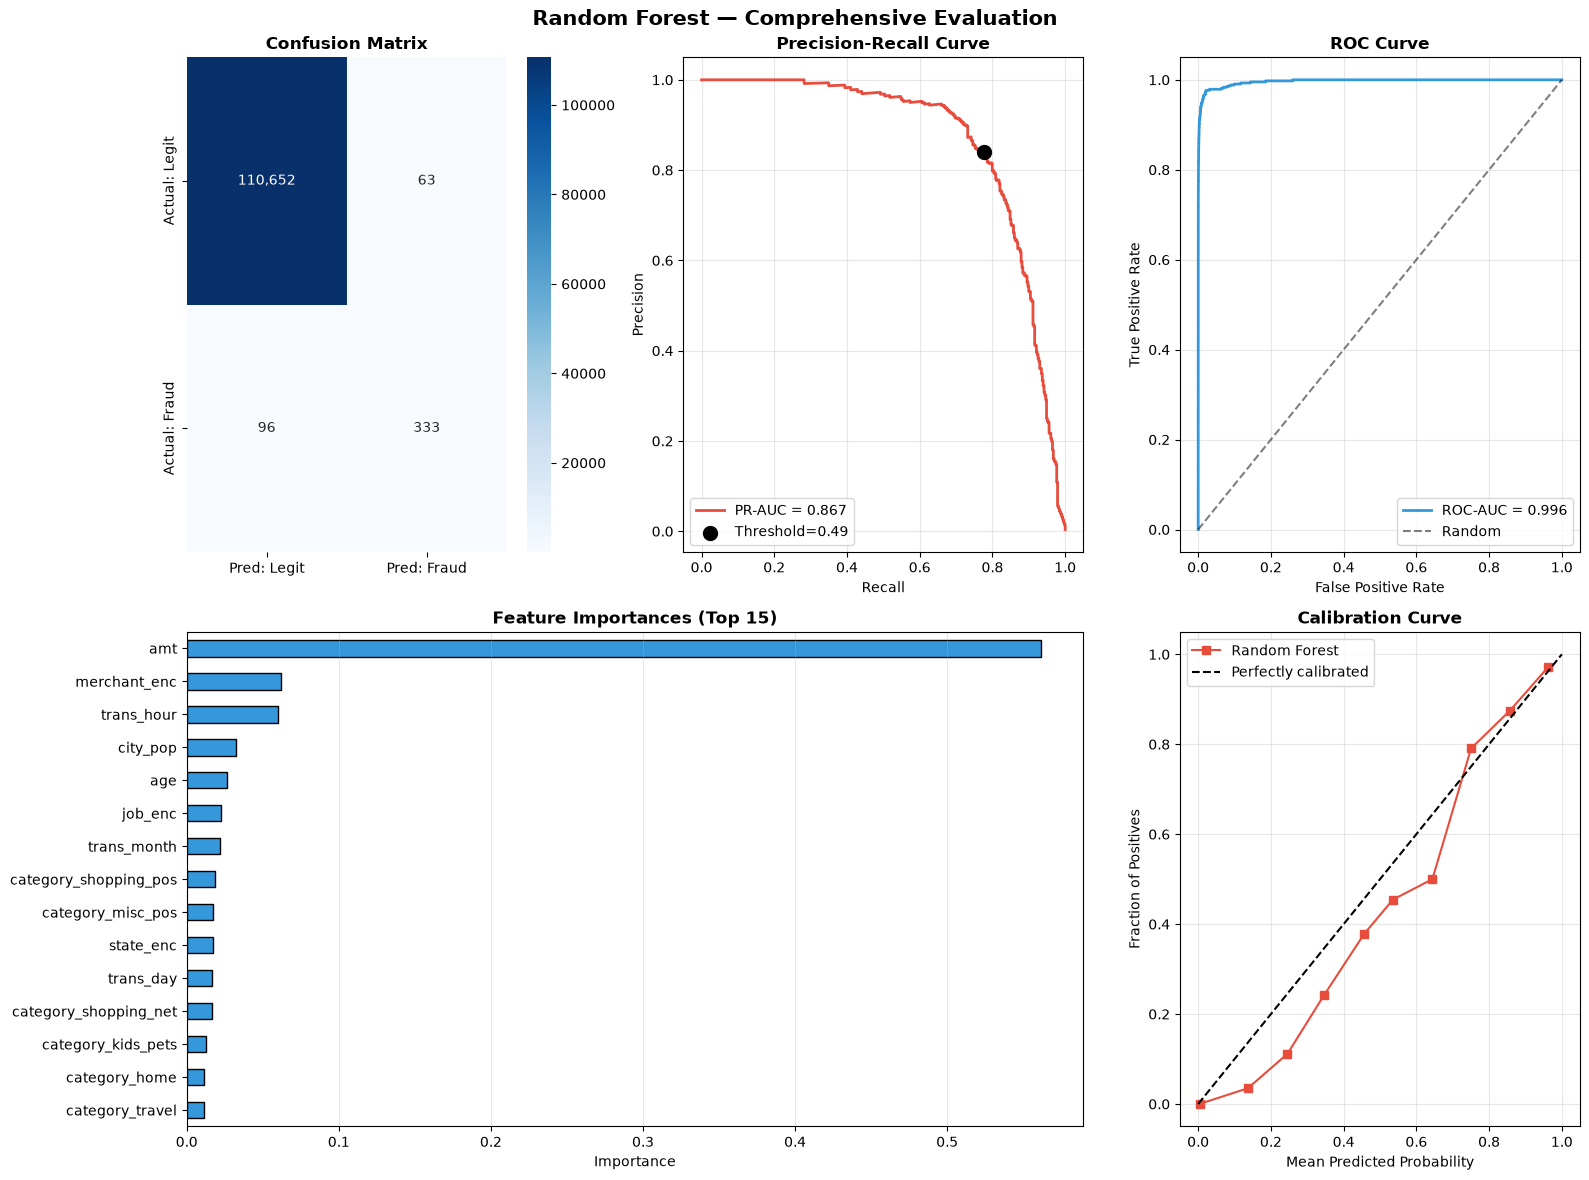

In [ ]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    np.array([[tn, fp], [fn, tp]]),
    annot=True, fmt=',d', cmap='Blues', ax=ax1,
    xticklabels=['Pred: Legit', 'Pred: Fraud'],
    yticklabels=['Actual: Legit', 'Actual: Fraud']
)
ax1.set_title('Confusion Matrix', fontweight='bold')

# 2. Precision-Recall Curve
ax2 = fig.add_subplot(gs[0, 1])
prec_c, rec_c, _ = precision_recall_curve(y_te, y_proba_rf)
ax2.plot(rec_c, prec_c, color='#e74c3c', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax2.scatter([recall], [precision], s=100, color='black', zorder=5,
            label=f'Threshold={BEST_THRESHOLD:.2f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. ROC Curve
ax3 = fig.add_subplot(gs[0, 2])
fpr_c, tpr_c, _ = roc_curve(y_te, y_proba_rf)
ax3.plot(fpr_c, tpr_c, color='#3498db', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Feature Importance (Top 15)
ax4 = fig.add_subplot(gs[1, :2])
importances = pd.Series(best_rf.feature_importances_, index=X_tr.columns)
importances.sort_values(ascending=True).tail(15).plot(
    kind='barh', ax=ax4, color='#3498db', edgecolor='black'
)
ax4.set_title('Feature Importances (Top 15)', fontweight='bold')
ax4.set_xlabel('Importance')
ax4.grid(axis='x', alpha=0.3)

# 5. Calibration Curve
ax5 = fig.add_subplot(gs[1, 2])
frac_pos, mean_pred = calibration_curve(y_te, y_proba_rf, n_bins=10)
ax5.plot(mean_pred, frac_pos, 's-', color='#e74c3c', label='Random Forest')
ax5.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax5.set_xlabel('Mean Predicted Probability')
ax5.set_ylabel('Fraction of Positives')
ax5.set_title('Calibration Curve', fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

plt.suptitle('Random Forest — Comprehensive Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/evaluation_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 17: Error Analysis

Understanding **where the model fails** is as important as overall accuracy.

- **False Positives** — legitimate transactions flagged as fraud → customer friction
- **False Negatives** — actual fraud missed → financial loss

In [ ]:
test_analysis = test_pre.copy()
test_analysis['amt_actual']        = test_df['amt'].values  # test_df from Step 7, pre-scaling
test_analysis['fraud_probability'] = y_proba_rf
test_analysis['predicted_fraud']   = y_pred_rf
test_analysis['error_type']        = 'Correct'
test_analysis.loc[(y_pred_rf==1) & (y_te==0), 'error_type'] = 'False Positive'
test_analysis.loc[(y_pred_rf==0) & (y_te==1), 'error_type'] = 'False Negative'

fp_df = test_analysis[test_analysis['error_type'] == 'False Positive']
fn_df = test_analysis[test_analysis['error_type'] == 'False Negative']

print('=== False Positives (Legitimate flagged as Fraud) ===')
print(f'Count                  : {len(fp_df):,}')
print(f'Avg transaction amount : ${fp_df["amt_actual"].mean():.2f}') 
print(f'Avg fraud probability  : {fp_df["fraud_probability"].mean():.4f}')

print('\n=== False Negatives (Fraud missed by model) ===')
print(f'Count                  : {len(fn_df):,}')
print(f'Avg transaction amount : ${fn_df["amt_actual"].mean():.2f}')   
print(f'Avg fraud probability  : {fn_df["fraud_probability"].mean():.4f}')

=== False Positives (Legitimate flagged as Fraud) ===
Count                  : 63
Avg transaction amount : $822.45
Avg fraud probability  : 0.6737

=== False Negatives (Fraud missed by model) ===
Count                  : 96
Avg transaction amount : $225.46
Avg fraud probability  : 0.2156


## Step 18: Save Final Model and Metadata

In [ ]:
joblib.dump(best_rf, MODELS_DIR / 'model.joblib')
joblib.dump(best_rf, BACKEND_ARTIFACTS_DIR / 'model.joblib')

feat_cols = X_tr.columns.tolist()
metrics_out = {
    'threshold':   BEST_THRESHOLD,
    'precision':   precision,
    'recall':      recall,
    'f1_score':    f1,
    'pr_auc':      pr_auc,
    'roc_auc':     roc_auc,
    'confusion_matrix': {
        'true_negatives':  int(tn), 'false_positives': int(fp),
        'false_negatives': int(fn), 'true_positives':  int(tp),
    },
    'train_rows':       int(len(X_tr)),
    'test_rows':        int(len(X_te)),
    'train_fraud_rate': float(y_tr.mean()),
    'test_fraud_rate':  float(y_te.mean()),
    'best_params':      search.best_params_,
    'feature_importances': dict(zip(feat_cols, best_rf.feature_importances_.tolist())),
}

with open(MODELS_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
with open(BACKEND_ARTIFACTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print('Saved:')
print('  models/model.joblib')
print('  models/scaler.joblib')
print('  models/freq_maps.joblib')
print('  models/feature_cols.json')
print('  models/metrics.json')
print()
print('=' * 50)
print('  TRAINING COMPLETE')
print(f'  Precision : {precision:.2%}')
print(f'  Recall    : {recall:.2%}')
print(f'  F1-Score  : {f1:.2%}')
print(f'  PR-AUC    : {pr_auc:.2%}')
print(f'  Threshold : {BEST_THRESHOLD:.2f}')
print('=' * 50)

Saved:
  models/model.joblib
  models/scaler.joblib
  models/freq_maps.joblib
  models/feature_cols.json
  models/metrics.json

  TRAINING COMPLETE
  Precision : 84.09%
  Recall    : 77.62%
  F1-Score  : 80.73%
  PR-AUC    : 86.71%
  Threshold : 0.49
